# 02 · The wrong lesson

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AreevAI/dejadb/blob/main/examples/colab/02_the_wrong_lesson.ipynb)

*Segment: "What happens when an agent learns the wrong lesson, relies on
outdated information, or changes its behaviour without oversight?" — the
question this event is named after.*

It's month-end close at a mid-size company. The invoice agent's payment
gateway starts rejecting calls. A lesson gets proposed, reviewed, and approved —
reasonably, on the evidence available. It's also **wrong**. This notebook is
about the machinery that catches that: measurement, a system-filed revert
proposal, audited rollback — and then an LLM pass that finds the *real* story
in facts the agent had all along.

In [1]:
try:
    from dejadb.helpers import *              # ships with dejadb >= 1.0.4
except ImportError:
    import subprocess, sys
    if subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                       "dejadb>=1.0.4", "matplotlib"]).returncode:
        raise SystemExit(
            "This notebook needs dejadb >= 1.0.4 for `dejadb.helpers`, which pip "
            "could not install. If 1.0.4 is not on PyPI yet, run from a repo "
            "checkout instead: see examples/colab/README.md.")
    from dejadb.helpers import *
import dejadb, json, pathlib
print("dejadb", dejadb.__version__)

dejadb 1.0.3


## Month-end close, and a reasonable decision

The agent has been keeping ordinary records — including two facts nobody has
connected yet:

In [2]:
db = fresh("finance.db", ns="finance", actor="user:controller")

db.add_fact("payment_gateway", "credential_expiry", "2026-07-30")
db.add_fact("payment_gateway", "credential_owner", "finance-ops team")
db.add_fact("month_end_close", "deadline", "2026-08-02")

for i in range(1, 5):
    db.record_tool_call("payment_gateway", f"401 unauthorized - token rejected (call {i})",
                        is_error=True, thread="close-jul")
db.record_tool_call("payment_gateway", '{"ok":true}', thread="close-jul")

db.waiser_run(full_sweep=True)
lesson = show_recs(db)[0]
db.apply_recommendation(lesson["hash"],
    because="gateway unstable during close — queue invoices for manual review")

  [medium] [reversible ] Tool "payment_gateway" failed 4 times (80% of calls): # unauthorized - token rejected (call #)


'{"hash":"ae4053d94e88728c603a68fb115f53f732fe33d04c70f0f1e953c1ba003abc54","rollbackable":true}'

Defensible, given what was known. But the lesson treats a **symptom** — and
the rejections keep coming, manual queue or not:

In [3]:
for i in range(5, 11):
    db.record_tool_call("payment_gateway", f"401 unauthorized - token rejected (call {i})",
                        is_error=True, thread="close-jul-b")
print("6 more rejections — same signature, lesson or no lesson")

6 more rejections — same signature, lesson or no lesson


## The Verify gate raises its hand

Two days later, the scheduled sweep re-measures the applied lesson against the
baseline recorded when it was adopted — and files its own case against it:

  tool_error_recurrence: baseline=0 → current=6  — REGRESSED
  [high  ] [reversible ] Applied recommendation regressed: tool_error_recurrence moved 0.0 → 6.0


chart exported → regression.png


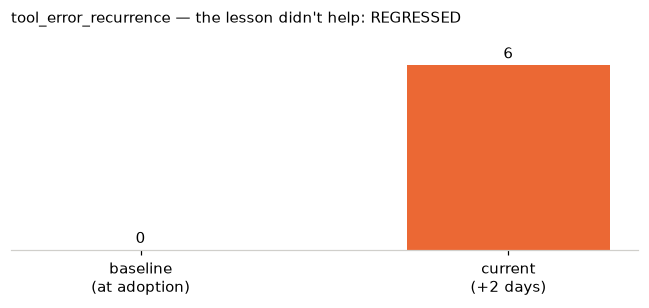

In [4]:
with days_later(2):
    db.waiser_run(full_sweep=True)

o = outcomes(db)[0]
show_recs(db)
bar(["baseline\n(at adoption)", "current\n(+2 days)"], [o["baseline"], o["current"]],
    colors=[BLUE, ORANGE], save="regression.png",
    title="tool_error_recurrence — the lesson didn't help: REGRESSED")

## Roll it back — audited

The system proposed; a human decides. Rollback retracts exactly the grains the
adoption created, requires a reason, and keeps the whole episode on the
record:

In [5]:
db.rollback_recommendation(lesson["hash"],
    because="lesson treated a symptom — invoices were late and errors continued")
db.dismiss_recommendation(recs(db)[0]["hash"],
    "actioned — original lesson rolled back")

print("lesson still live?",
      any(f["relation"] == "fails_with" for f in facts(db, "payment_gateway")))

lesson still live? False


## Now find the *real* lesson — with an LLM, governed

The clues were in memory the whole time: a credential that expired **July 30**,
401s starting right after, a close deadline of **August 2**. No deterministic
rule connects those. An LLM discovery pass can — and whatever it drafts still
has to survive grounding and verification, then wait for review like any other
proposal:

In [6]:
model = auto_model()
print("LLM:", model or "none configured — skipping discovery (deterministic floor only)")
if model:
    db.waiser_run(full_sweep=True, model=model)
    discovered = False
    for r in show_recs(db):
        if r["analyzer"].startswith("waiser.llm"):
            discovered = True
            db.apply_recommendation(r["hash"],
                because="root cause confirmed — credential rotation scheduled with finance-ops")
            print("\nadopted the model's finding — with a named reviewer and a reason")
    if not discovered:
        print("(no draft survived GROUND→VERIFY this run — drafts are filtered, never guaranteed)")
    for r in recs(db):                    # the symptom-level re-proposal, now redundant
        db.dismiss_recommendation(r["hash"],
            "symptom of the credential issue — rotation in progress")

LLM: openrouter:openai/gpt-4o-mini


  [high  ] [reversible ] Tool "payment_gateway" failed 10 times (91% of calls): # unauthorized - token rejected (call #)


  [low   ] [reversible ] Credential expiry date is before the month-end close deadline, potentially causing operational issues.

adopted the model's finding — with a named reviewer and a reason


> **Where the LLM fits.** `auto_model()` picks up an `ANTHROPIC_API_KEY` /
> `OPENAI_API_KEY` / `OPENROUTER_API_KEY` from Colab's Secrets panel or the
> environment. With a key, the same sweep adds an LLM **discovery** pass whose
> drafts must survive GROUND (does the cited evidence exist?) and VERIFY (an
> independent soundness check, 0.75 confidence floor) before they may even
> *queue* — the model never gets write access. Without a key, the deterministic
> analyzers still run: the floor is always keyless.

## Outdated and harmful knowledge

Corrections never edit history — outdated facts are **superseded** (the old
value remains as auditable history), and content that must go entirely is
tombstoned via `forget` (with file-level crypto-erasure behind it):

In [7]:
h = db.add_fact("payment_gateway", "remittance_inbox", "ap@example.com")    # outdated
db.supersede(h, "fact", json.dumps({"subject": "payment_gateway",
    "relation": "remittance_inbox", "object": "payables@example.com"}))
for v in json.loads(db.history("payment_gateway", "remittance_inbox")):
    print(f"[{'superseded' if v['superseded_by'] else 'LIVE      '}] {v['object']}")

bad = db.add_fact("payment_gateway", "workaround", "skip the approval check")  # harmful
db.forget(bad)
print("harmful grain live?",
      any(f["relation"] == "workaround" for f in facts(db, "payment_gateway")))

[LIVE      ] payables@example.com
[superseded] ap@example.com
harmful grain live? False


## The whole episode, on the record

In [8]:
audit(db)

  [applied    ] Credential expiry date is before the month-end close deadline, pot
  [rejected   ] Tool "payment_gateway" failed 10 times (91% of calls): # unauthori
  [rejected   ] Applied recommendation regressed: tool_error_recurrence moved 0.0 
  [rolled_back] Tool "payment_gateway" failed 4 times (80% of calls): # unauthoriz


One incident, five artifacts an auditor can replay: the adoption (with its
reason), the measured regression, the system-filed revert, the rollback (with
its reason), and the LLM-discovered root cause — adopted under the same review
gate as everything else.